In [1]:
import numpy as np
from scipy.stats import norm as gaussian
from dataclasses import dataclass, field
from textwrap import dedent

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")

## Lloyd-Max Codebook

In [2]:
@dataclass(frozen=True)
class LloydMaxCodebook:

    bits: int
    tol: float = field(default=1e-8)
    k: int = field(init=False)
    boundaries: np.ndarray = field(init=False)
    centroids: np.ndarray = field(init=False)
    distortion: float = field(init=False)

    
    def __post_init__(self):
        object.__setattr__(self, "k", 2 ** self.bits)

        assert self.bits <= 6, "bits > 6 not supported"

        boundaries = np.concatenate([[-np.inf], [gaussian.ppf(i / self.k) for i in range(1, self.k)], [np.inf]])
        centroids = self._compute_centroids(boundaries)

        while True:
            old_boundaries = boundaries.copy()
            boundaries = self._compute_boundaries(centroids)
            centroids = self._compute_centroids(boundaries)
            if np.max(np.abs(boundaries[1:-1] - old_boundaries[1:-1])) < self.tol:
                break

        object.__setattr__(self, "boundaries", boundaries)
        object.__setattr__(self, "centroids", centroids)
        object.__setattr__(self, "distortion", self._compute_distortion(boundaries, centroids))

    def _compute_centroids(self, boundaries: np.ndarray) -> np.ndarray:
        centroids = []
        for b1,b2 in zip(boundaries[:-1], boundaries[1:]):
            c = (gaussian.pdf(b1) - gaussian.pdf(b2))/(gaussian.cdf(b2) - gaussian.cdf(b1))
            centroids.append(c)
        return np.array(centroids)

    def _compute_boundaries(self, centroids: np.ndarray) -> np.ndarray:
        boundaries = [-np.inf]
        for c1, c2 in zip(centroids[:-1], centroids[1:]):
            b = (c1 + c2) / 2
            boundaries.append(b)
        boundaries.append(np.inf)
        return np.array(boundaries)

    def _compute_distortion(self, boundaries: np.ndarray, centroids: np.ndarray) -> float:

        assert len(centroids) == len(boundaries) - 1, f"Incorrect sizes of centroids and boundaries, got {len(boundaries)}, {len(centroids)}, expected difference 1"
        acc = 0
        for b1, b2, c in zip(boundaries[:-1], boundaries[1:], centroids):
            p = gaussian.cdf(b2) - gaussian.cdf(b1)
            acc += p * c * c

        return 1 - acc
    
    def __repr__(self) -> str:
        return dedent(f"""
        {self.bits}-Bit Lloyd-Max Codebook
        Bins: {self.k}
        Tol: {self.tol}
        Boundaries: {','.join(f'{b:.2f}' for b in self.boundaries)}"
        Centroids: {','.join(f'{c:.2f}' for c in self.centroids)}"
        Distortion: {self.distortion}""")
    
    def visualize(self) -> None:

        bins = []

        for b1, b2 in zip(self.boundaries[:-1], self.boundaries[1:]):
            bins.append(float(gaussian.cdf(b2) - gaussian.cdf(b1)))

        print(f"Bin Probability Masses: {','.join(f'{b:.3f}' for b in bins)}")
        print(f"Mean: {np.mean(bins)} | Std: {np.std(bins)}")

        # Build x-grid over the finite support of self.boundaries with a little margin
        finite_b = self.boundaries[np.isfinite(self.boundaries)]
        x_min, x_max = finite_b.min() - 0.5, finite_b.max() + 0.5
        x = np.linspace(x_min, x_max, 2000)
        y = gaussian.pdf(x)

        fig, ax = plt.subplots(figsize=(12, 6))

        # Normal distribution curve + fill
        ax.plot(x, y, color="C0", linewidth=2.5, label="Normal PDF")
        ax.fill_between(x, y, 0, color="C0", alpha=0.25)

        # Boundary lines (exclude +/- inf)
        for i, b in enumerate(finite_b):
            ax.axvline(
                b,
                color="black",
                linestyle="--",
                linewidth=1,
                alpha=0.7,
                label="Boundaries" if i == 0 else None
            )

        # Centroids as points on the Gaussian surface
        centroid_y = gaussian.pdf(self.centroids)
        ax.scatter(
            self.centroids,
            centroid_y,
            s=35,
            color="C3",
            edgecolor="white",
            linewidth=0.6,
            zorder=5,
            label="Centroids"
        )

        ax.set_title(f"Lloyd-Max Quantizer (bits={self.bits}, levels={2**self.bits})")
        ax.set_xlabel("x")
        ax.set_ylabel("PDF")
        ax.set_xlim(x_min, x_max)
        ax.legend(loc="upper right")
        plt.tight_layout()
        plt.show()

    def quantize(self, x: np.ndarray) -> np.ndarray:
        indices = np.searchsorted(self.boundaries[1:-1], x)

        if self.bits <= 8:
            return indices.astype(np.uint8)
        else:
            return indices.astype(np.uint16)

    def dequantize(self, x: np.ndarray) -> np.ndarray:

        return self.centroids[x]   
        


4-Bit Lloyd-Max Codebook
Bins: 16
Tol: 1e-08
Boundaries: -inf,-2.40,-1.84,-1.44,-1.10,-0.80,-0.52,-0.26,-0.00,0.26,0.52,0.80,1.10,1.44,1.84,2.40,inf"
Centroids: -2.73,-2.07,-1.62,-1.26,-0.94,-0.66,-0.39,-0.13,0.13,0.39,0.66,0.94,1.26,1.62,2.07,2.73"
Distortion: 0.009501008008192313
Bin Probability Masses: 0.008,0.024,0.043,0.060,0.076,0.089,0.097,0.102,0.102,0.097,0.089,0.076,0.060,0.043,0.024,0.008
Mean: 0.0625 | Std: 0.03247800456240541


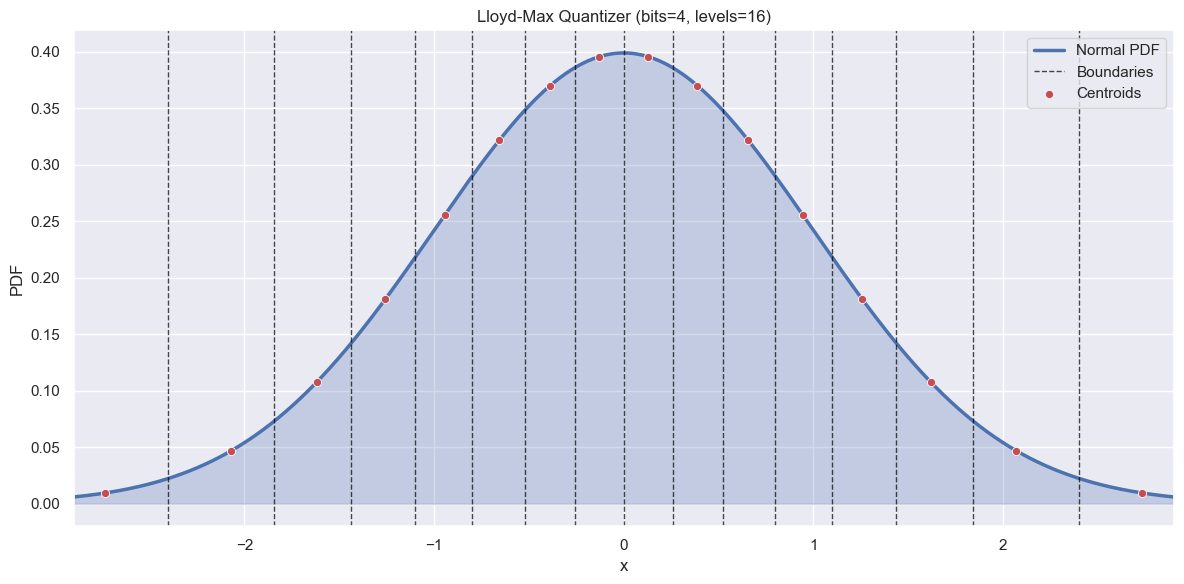

In [3]:
bits = 4
codebook = LloydMaxCodebook(bits)

print(codebook)
codebook.visualize()

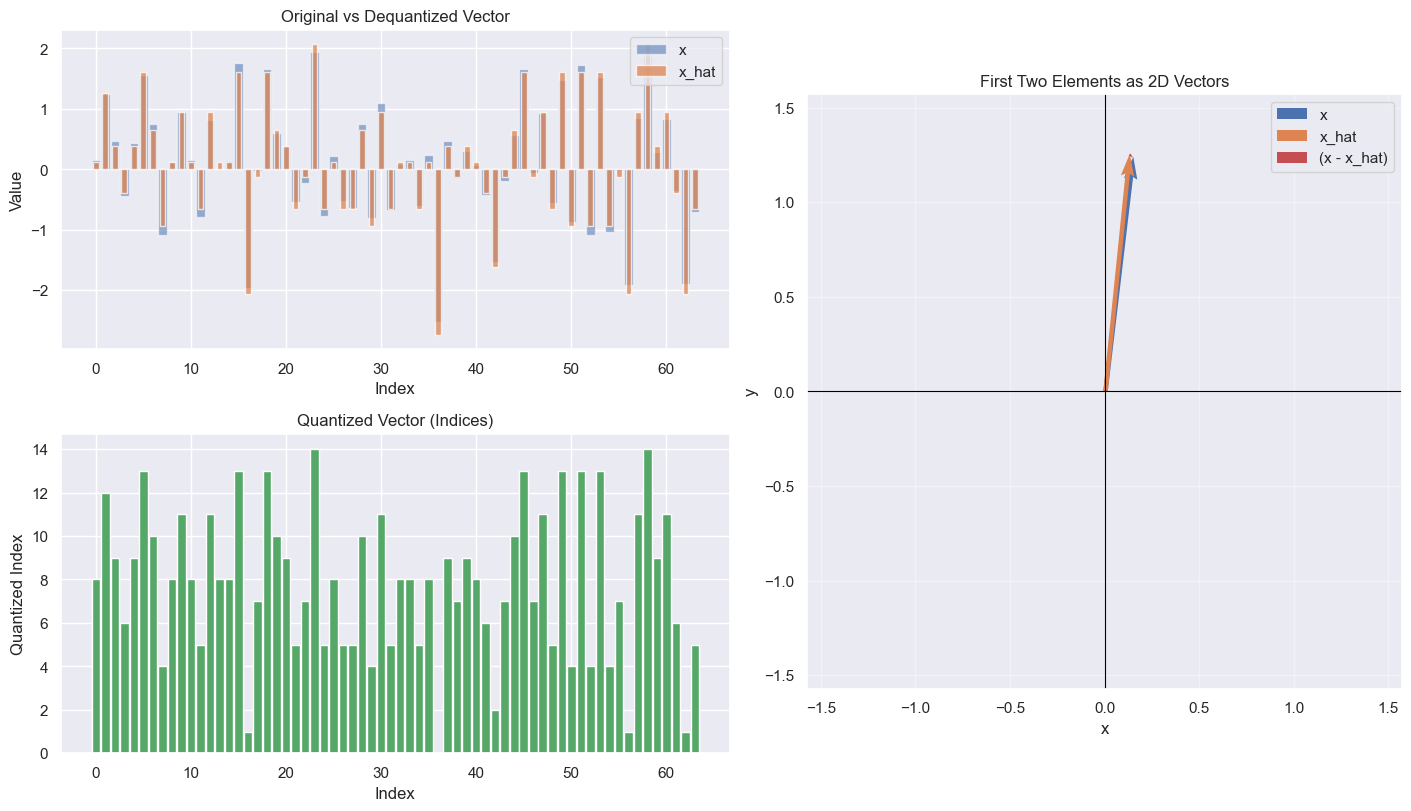

MSE: 0.009253764222253012


In [4]:
x = np.random.normal(size=64)
x_q = codebook.quantize(x)
x_hat = codebook.dequantize(x_q)


idx = np.arange(len(x))
err = x - x_hat

# Use a balanced layout so left bar charts keep enough width
fig = plt.figure(figsize=(14, 8), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=[1.8, 1.6], height_ratios=[1, 1])

axes = np.empty(3, dtype=object)
axes[0] = fig.add_subplot(gs[0, 0])                 # top-left
axes[1] = fig.add_subplot(gs[1, 0], sharex=axes[0]) # bottom-left
axes[2] = fig.add_subplot(gs[:, 1])                 # right (spans both rows)

# Original and dequantized vectors
axes[0].bar(idx, x, width=0.9, alpha=0.55, label="x", color="C0")
axes[0].bar(idx, x_hat, width=0.6, alpha=0.75, label="x_hat", color="C1")
axes[0].set_title("Original vs Dequantized Vector")
axes[0].set_xlabel("Index")
axes[0].set_ylabel("Value")
axes[0].legend(loc="upper right")

# Quantized indices
axes[1].bar(idx, x_q, width=0.9, color="C2")
axes[1].set_title("Quantized Vector (Indices)")
axes[1].set_xlabel("Index")
axes[1].set_ylabel("Quantized Index")

# Cartesian plane: first two elements as 2D vectors
ax2 = axes[2]
ax2.quiver(0, 0, x[0], x[1], angles="xy", scale_units="xy", scale=1, color="C0", label="x")
ax2.quiver(0, 0, x_hat[0], x_hat[1], angles="xy", scale_units="xy", scale=1, color="C1", label="x_hat")
ax2.quiver(x_hat[0], x_hat[1], err[0], err[1], angles="xy", scale_units="xy", scale=1, color="C3", label="(x - x_hat)")

m = np.max(np.abs(np.vstack([x[:2], x_hat[:2], err[:2]]))) * 1.25
ax2.set_xlim(-m, m)
ax2.set_ylim(-m, m)
ax2.set_aspect("equal", adjustable="box")
ax2.set_box_aspect(1)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.grid(True, alpha=0.35)
ax2.set_title("First Two Elements as 2D Vectors")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.legend(loc="upper right")

plt.show()

print(f"MSE: {np.pow((x - x_hat), 2).mean()}")


## Random Rotation to transform to Gaussian

In [5]:
def random_orthogonal(d: int, seed: int | None = None) -> np.ndarray:
    """
    Sample a d x d orthogonal matrix uniformly (Haar measure) on O(d).
    
    Uses QR decomposition of a Gaussian matrix with sign correction
    to ensure uniform distribution over the orthogonal group.
    
    Returns R with shape (d, d) satisfying R @ R.T = I.
    """
    rng = np.random.default_rng(seed)
    A = rng.standard_normal((d, d))
    Q, R_mat = np.linalg.qr(A)
    # Sign-correct so the result is Haar-distributed (not just arbitrarily orthogonal).
    # Each column of Q gets multiplied by the sign of the corresponding diagonal of R_mat.
    sign = np.sign(np.diag(R_mat))
    return Q * sign

In [6]:
rng = np.random.default_rng(42)
d = 8192

R = random_orthogonal(d, seed=42)

# Orthogonality
np.testing.assert_allclose(R @ R.T, np.eye(d), atol=1e-10)
np.testing.assert_allclose(R.T @ R, np.eye(d), atol=1e-10)


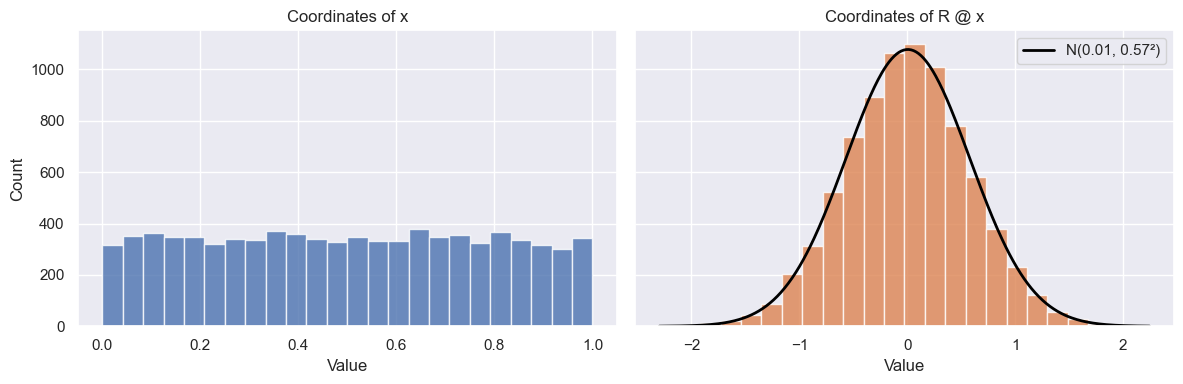

In [7]:

x = np.random.uniform(size=d)
x_R = R @ x


fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax[0].hist(x, bins=24, color="C0", alpha=0.8, edgecolor="white")
ax[0].set_title("Coordinates of x")
ax[0].set_xlabel("Value")
ax[0].set_ylabel("Count")

counts, bin_edges, _ = ax[1].hist(x_R, bins=24, color="C1", alpha=0.8, edgecolor="white")
ax[1].set_title("Coordinates of R @ x")
ax[1].set_xlabel("Value")

# Fitted Gaussian PDF, scaled to histogram counts
mu, sigma = np.mean(x_R), np.std(x_R, ddof=1)
x_pdf = np.linspace(bin_edges[0], bin_edges[-1], 400)
bin_w = bin_edges[1] - bin_edges[0]
y_pdf = gaussian.pdf(x_pdf, loc=mu, scale=sigma) * len(x_R) * bin_w
ax[1].plot(x_pdf, y_pdf, color="black", linewidth=2, label=f"N({mu:.2f}, {sigma:.2f}²)")
ax[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## Putting it together: PolarQuant

In [8]:
class PolarQuant:

    def __init__(self, bits: int, dim: int, tol: float = 1e-8, seed: int | None = None, R: np.ndarray | None = None):
        self.bits = bits
        self.dim = dim
        self.seed = seed
        self.sigma = 1.0 / np.sqrt(dim)
        self.codebook = LloydMaxCodebook(bits, tol)
        self.R = self._make_rotation() if R is None else R

    def _make_rotation(self) -> np.ndarray:
        rng = np.random.default_rng(self.seed)
        A = rng.standard_normal((self.dim, self.dim))
        Q, R_mat = np.linalg.qr(A)
        sign = np.sign(np.diag(R_mat))
        return Q * sign

    def encode(self, x: np.ndarray) -> tuple[float, np.ndarray]:
        """Returns (norm, indices). norm is fp32 scalar; indices is uint8[d]."""
        assert x.shape == (self.dim,), f"expected shape ({self.dim},), got {x.shape}"
        r = np.linalg.norm(x)
        x_tilde = x / r                      # unit sphere
        u = self.R @ x_tilde                 # rotate: now coords ~ N(0, 1/d)
        u_scaled = u / self.sigma            # rescale to N(0, 1) for codebook
        indices = self.codebook.quantize(u_scaled)
        return float(r), indices

    def decode_rotated(self, indices: np.ndarray) -> np.ndarray:
        """Return u_hat (rotated, original-scale, no norm applied)."""
        return self.codebook.dequantize(indices) * self.sigma

    def decode(self, r: float, indices: np.ndarray) -> np.ndarray:
        u_hat = self.decode_rotated(indices)
        return r * (self.R.T @ u_hat)

In [9]:
pq = PolarQuant(bits, dim=d, seed=42)

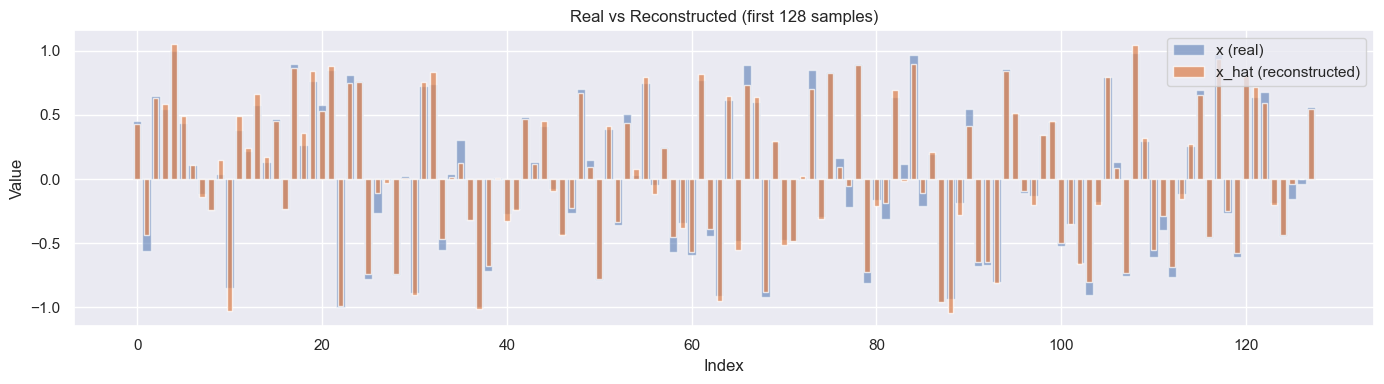

MSE: 0.003271


In [10]:

x = np.random.uniform(-1, 1, d)
r, x_quant = pq.encode(x)
x_hat = pq.decode(r, x_quant)

n_plot = 128  # plot a subset for readability
idx = np.arange(n_plot)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(idx, x[:n_plot], width=0.9, alpha=0.55, label="x (real)", color="C0")
ax.bar(idx, x_hat[:n_plot], width=0.6, alpha=0.75, label="x_hat (reconstructed)", color="C1")
ax.set_title("Real vs Reconstructed (first 128 samples)")
ax.set_xlabel("Index")
ax.set_ylabel("Value")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

mse = np.mean((x - x_hat) ** 2)
print(f"MSE: {mse:.6f}")

In [11]:
rng = np.random.default_rng(42)
n_trials = 1000
errors = []

for _ in range(n_trials):
    x = rng.uniform(-1, 1, d)

    r, q_idx = pq.encode(x)
    x_hat = pq.decode(r, q_idx)

    errors.append(np.linalg.norm(x - x_hat) ** 2 / np.linalg.norm(x) ** 2)

mean_err = np.mean(errors)
expected = pq.codebook.distortion
print(f"Mean ||x - x_hat||^2: {mean_err:.4f}   (theoretical ~{expected:.4f})")

Mean ||x - x_hat||^2: 0.0095   (theoretical ~0.0095)


## Quantized Johnson-Lindenstrauss

1-Bit Inner Product Quantization. x is encoded as magnitude `rho` and sign as sign of `G @ x`, where `G` is `m` sampled gaussian vectors. Cannot de-quantize, but can estimate inner product with vector `y` while in quantized form `rho`, `sign`.

In [12]:
class JLQuantizer:

    def __init__(self, dim: int, m: int, seed: int | None = None):
        self.dim = dim
        self.m = m
        self._seed = seed
        rng = np.random.default_rng(self._seed)
        self.G = rng.standard_normal((m, dim))

    def encode(self, x: np.ndarray) -> tuple[float, np.ndarray]:
        rho = np.linalg.norm(x)
        sign_bits = np.sign(self.G @ x).astype(np.int8)
        return float(rho), sign_bits

    def estimate_ip(self, rho: float, sign_bits: np.ndarray, y: np.ndarray) -> float:
        gy = self.G @ y
        return float(np.sqrt(np.pi / 2) * rho * np.mean(sign_bits * gy))

    @property
    def seed(self) -> int:
        return self._seed

    def set_seed(self, new_seed: int) -> None:
        self._seed = new_seed
        rng = np.random.default_rng(self._seed)
        self.G = rng.standard_normal(self.G.shape)

In [13]:
jlq = JLQuantizer(dim=d, m=d, seed=42)

In [14]:
x = np.random.normal(size=d)
x /= np.linalg.norm(x)
xrho, xsign = jlq.encode(x)
y = x - (np.random.normal(size=d) * 0.01)
y /= np.linalg.norm(y)

print(f"True dot product: {np.dot(x, y)}")
print(f"Estimated dot product: {jlq.estimate_ip(xrho, xsign, y)}")


True dot product: 0.7365094011234806
Estimated dot product: 0.7180414162244184


## Putting it together: TurboQuant

In [15]:
@dataclass(frozen=True)
class QuantizedVector:
    x_r: float
    x_indices: np.ndarray
    res_r: float
    res_signs: np.ndarray


class TurboQuant:

    def __init__(self, bits: int, dim: int, m: int, tol: float = 1e-8, seed: int | None = None):
        self.bits = bits
        self.dim = dim
        self.m = m
        self._seed = seed
        self.sigma = 1 / np.sqrt(dim)

        self.mse_quantizer = PolarQuant(bits - 1, dim, tol=tol, seed=seed)
        # Use a different seed for JL so the projection matrix G is independent
        # of the rotation matrix R. Critical for QJL unbiasedness theory.
        seed_jl = None if seed is None else seed + 1
        self.ip_quantizer = JLQuantizer(dim, m, seed=seed_jl)

        self.R = self.mse_quantizer.R   # alias for convenience

    def quantize(self, x: np.ndarray) -> QuantizedVector:
        # Step 1: MSE-encode x via PolarQuant.
        x_r, x_indices = self.mse_quantizer.encode(x)

        # Step 2: Compute the residual e = u - u_hat in rotated space.
        # u is the rotated unit-sphere version of x; u_hat is its MSE reconstruction.
        u = self.R @ (x / x_r)
        u_hat = self.mse_quantizer.decode_rotated(x_indices)
        e = u - u_hat

        # Step 3: Sketch the residual (NOT x itself) with JL.
        res_r, res_signs = self.ip_quantizer.encode(e)

        return QuantizedVector(x_r, x_indices, res_r, res_signs)

    def estimate_ip(self, x_q: QuantizedVector, y: np.ndarray) -> float:
        # Rotate the query once, share between MSE and JL terms.
        y_rot = self.R @ y

        # Term 1: MSE contribution = r * <u_hat, R y>.
        u_hat = self.mse_quantizer.decode_rotated(x_q.x_indices)
        mse_contrib = x_q.x_r * np.dot(u_hat, y_rot)

        # Term 2: QJL estimate of r * <e, R y>.
        qjl_contrib = x_q.x_r * self.ip_quantizer.estimate_ip(
            x_q.res_r, x_q.res_signs, y_rot
        )

        return mse_contrib + qjl_contrib

In [55]:
bits = 4
dim = 1024
m = dim

tq = TurboQuant(bits, dim, m)
x = np.random.uniform(-1, 1, dim)
x = x / np.linalg.norm(x)
y = np.random.uniform(-1, 1, dim)
y = y / np.linalg.norm(y)

x_tq = tq.quantize(x)
x_r, x_signs = tq.ip_quantizer.encode(x)
print(f"Inner Product: {float(np.dot(x, y)):.5f}")
print(f"Estimated 1-Bit QJL Inner Product: {tq.ip_quantizer.estimate_ip(x_r, x_signs, y)}")
print(f"Estimated {bits}-Bit TurboQuant Inner Product: {tq.estimate_ip(x_tq, y)}")

Inner Product: 0.03113
Estimated 1-Bit QJL Inner Product: 0.11900652157331763
Estimated 4-Bit TurboQuant Inner Product: 0.031899822943929325
